# Radial Basis Function Network (RBFN) - TensorFlow / Keras

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score

# =========================================================
# 1. Load Iris Dataset
# =========================================================
iris = load_iris()
X = iris.data
y = iris.target

print(f"Feature Shape: {X.shape}")
print(f"Labels Shape : {y.shape}")

# =========================================================
# 2. Train/Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================
# 3. Feature Scaling
# =========================================================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# 4. Define RBF Parameters
# =========================================================
NUM_CENTERS = 10
BETA = 1.0

# =========================================================
# 5. Use KMeans to Find RBF Centers
# =========================================================
kmeans = KMeans(n_clusters=NUM_CENTERS, random_state=42, n_init='auto')
kmeans.fit(X_train)
centers = kmeans.cluster_centers_

print(f"Centers Shape: {centers.shape}")

# =========================================================
# 6. Custom RBF Layer
# =========================================================
# UPDATED: Using keras.utils instead of keras.saving
@keras.utils.register_keras_serializable(package="CustomLayers")
class RBFLayer(layers.Layer):
    def __init__(self, centers, beta, **kwargs):
        super(RBFLayer, self).__init__(**kwargs)
        self.centers = tf.constant(centers, dtype=tf.float32)
        self.beta = float(beta)

    def call(self, inputs):
        # Expand dimensions for broadcasting
        expanded_inputs = tf.expand_dims(inputs, axis=1)
        expanded_centers = tf.expand_dims(self.centers, axis=0)

        # Compute squared distance
        distances = tf.reduce_sum(
            tf.square(expanded_inputs - expanded_centers),
            axis=2)

        # Apply Gaussian RBF
        return tf.exp(-self.beta * distances)

    def get_config(self):
        # Required so the custom layer can be saved and loaded
        config = super(RBFLayer, self).get_config()
        config.update({
            "centers": self.centers.numpy().tolist(),
            "beta": self.beta
        })
        return config

# =========================================================
# 7. Build RBF Network
# =========================================================
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    RBFLayer(centers=centers, beta=BETA),
    layers.Dense(3, activation="softmax")
])

# =========================================================
# 8. Compile Model
# =========================================================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
    )

# =========================================================
# 9. Model Summary
# =========================================================
print("\nRBF Network Summary:")
model.summary()

# =========================================================
# 10. Train Model
# =========================================================
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
    )

# =========================================================
# 11. Evaluate Model
# =========================================================
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")

# =========================================================
# 12. Make Predictions
# =========================================================
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# =========================================================
# 13. Classification Accuracy
# =========================================================
accuracy = accuracy_score(y_test, predicted_classes)
print(f"Classification Accuracy: {accuracy:.4f}\n")

# =========================================================
# 14. Sample Predictions
# =========================================================
print("Sample Predictions:")
for i in range(10):
    print(f"True: {y_test[i]} | Predicted: {predicted_classes[i]}")

# =========================================================
# 15. Save Model
# =========================================================
model.save("rbf_network.keras")
print("\nRBF Network saved successfully!")

Feature Shape: (150, 4)
Labels Shape : (150,)
Centers Shape: (10, 4)

RBF Network Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rbf_layer (RBFLayer)            │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 123ms/step - accuracy: 0.1042 - loss: 1.2829 - val_accuracy: 0.0833 - val_loss: 1.2731
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.1250 - loss: 1.2732 - val_accuracy: 0.0833 - val_loss: 1.2635
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.1354 - loss: 1.2639 - val_accuracy: 0.0833 - val_loss: 1.2539
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1458 - loss: 1.2548 - val_accuracy: 0.1250 - val_loss: 1.2446
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.1562 - loss: 1.2458 - val_accuracy: 0.1250 - val_loss: 1.2354
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.1562 - loss: 1.2371 - val_accuracy: 0.1250 - val_loss: 1.2263
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.1667 - loss: 1.2283 - val_accuracy: 0.1667 - val_loss: 1.2173
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.2188 - loss: 1.2196 - val_accuracy: 0.2083 - val_loss

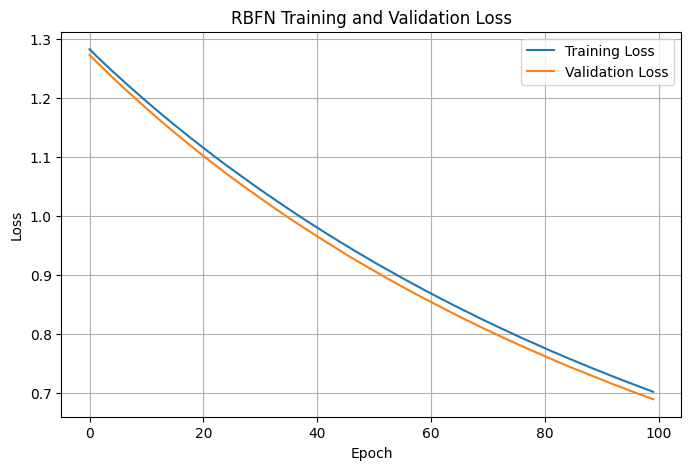

In [4]:
import matplotlib.pyplot as plt

# =========================================================
# Plot Loss
# =========================================================

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("RBFN Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()